In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
%pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
train_df = pd.read_csv("fraudTrain.csv")
test_df = pd.read_csv("fraudTest.csv")

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

Training dataset shape: (1296675, 23)
Testing dataset shape: (555719, 23)


In [7]:
train_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [6]:
train_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [8]:
train_df.tail()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0
1296674,1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.30,Jeffrey,Smith,M,135 Joseph Mountains,...,45.8433,-113.8748,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.565983,-114.186110,0


In [9]:
train_df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [11]:
print("Missing values:")
print(train_df.isnull().sum())

Missing values:
Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [12]:
print("Total missing values:", train_df.isnull().sum().sum())

Total missing values: 0


In [13]:
print(train_df["is_fraud"].value_counts())

is_fraud
0    1289169
1       7506
Name: count, dtype: int64


In [14]:
print(train_df["is_fraud"].value_counts(normalize=True) * 100)

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


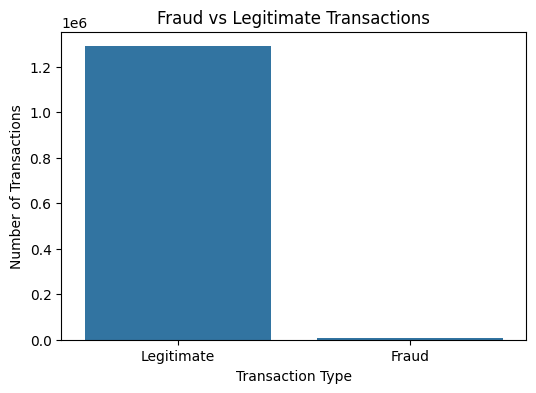

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(x="is_fraud", data=train_df)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

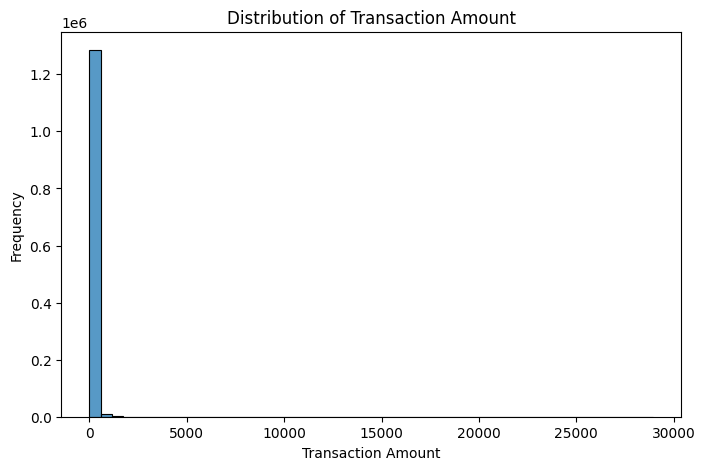

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=train_df,
    x="amt",
    bins=50
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

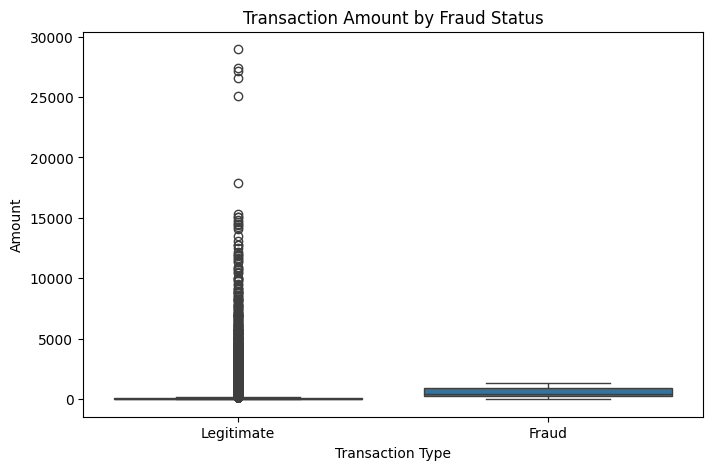

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="is_fraud",
    y="amt",
    data=train_df
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Transaction Type")
plt.ylabel("Amount")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

In [19]:
train_df["trans_date_trans_time"] = pd.to_datetime(
    train_df["trans_date_trans_time"]
)

test_df["trans_date_trans_time"] = pd.to_datetime(
    test_df["trans_date_trans_time"]
)

In [20]:
for df in [train_df, test_df]:
    df["hour"] = df["trans_date_trans_time"].dt.hour
    df["day"] = df["trans_date_trans_time"].dt.day
    df["month"] = df["trans_date_trans_time"].dt.month
    df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek

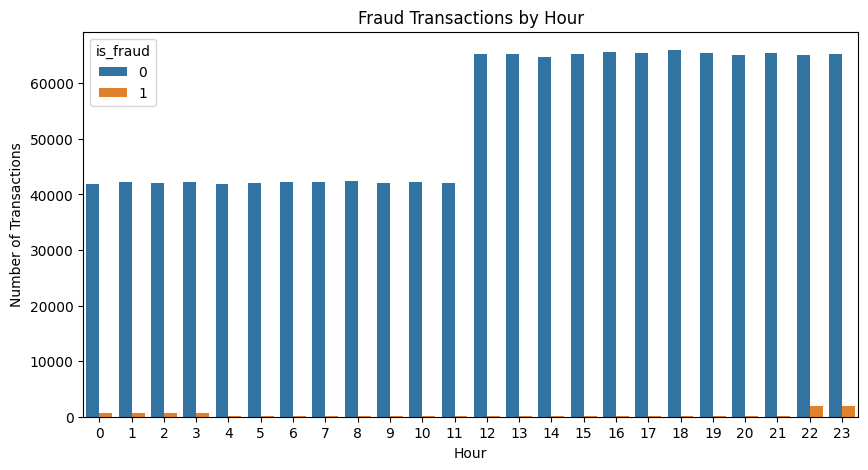

In [21]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=train_df,
    x="hour",
    hue="is_fraud"
)

plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")

plt.show()

In [22]:
drop_columns = [
    "Unnamed: 0",
    "trans_date_trans_time",
    "first",
    "last",
    "street",
    "trans_num",
    "dob",
    "cc_num"
]

train_df = train_df.drop(columns=drop_columns)
test_df = test_df.drop(columns=drop_columns)

In [23]:
high_cardinality_columns = [
    "merchant",
    "city",
    "state",
    "job"
]

train_df = train_df.drop(columns=high_cardinality_columns)
test_df = test_df.drop(columns=high_cardinality_columns)

In [24]:
train_df["gender"] = train_df["gender"].map({"F": 0, "M": 1})
test_df["gender"] = test_df["gender"].map({"F": 0, "M": 1})

In [25]:
train_df = pd.get_dummies(
    train_df,
    columns=["category"],
    dtype=int
)

test_df = pd.get_dummies(
    test_df,
    columns=["category"],
    dtype=int
)

In [26]:
X_train = train_df.drop("is_fraud", axis=1)
y_train = train_df["is_fraud"]

X_test = test_df.drop("is_fraud", axis=1)
y_test = test_df["is_fraud"]

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [27]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nFeatures:")
print(X_train.columns.tolist())

Training features: (1296675, 27)
Testing features: (555719, 27)

Features:
['amt', 'gender', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'hour', 'day', 'month', 'day_of_week', 'category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel']


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [29]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [30]:
y_pred_lr = logistic_model.predict(X_test_scaled)

In [31]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Legitimate", "Fraud"]
))

              precision    recall  f1-score   support

  Legitimate       1.00      0.94      0.97    553574
       Fraud       0.05      0.73      0.09      2145

    accuracy                           0.94    555719
   macro avg       0.52      0.84      0.53    555719
weighted avg       1.00      0.94      0.97    555719



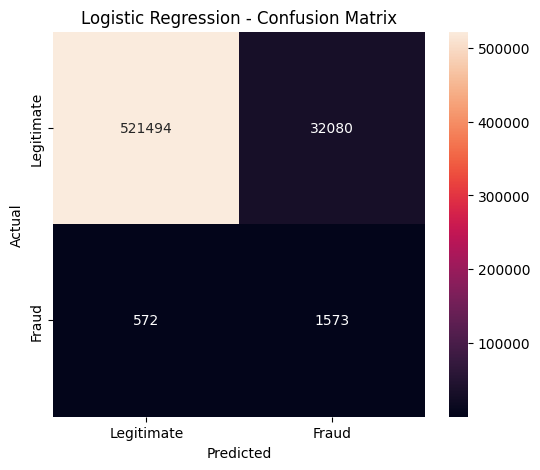

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [33]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=10,
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree training completed!")

Decision Tree training completed!


In [34]:
y_pred_dt = decision_tree.predict(X_test)

In [35]:
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["Legitimate", "Fraud"]
))

              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98    553574
       Fraud       0.09      0.95      0.17      2145

    accuracy                           0.96    555719
   macro avg       0.55      0.96      0.58    555719
weighted avg       1.00      0.96      0.98    555719



In [36]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [37]:
y_pred_rf = random_forest.predict(X_test)

In [38]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Legitimate", "Fraud"]
))

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    553574
       Fraud       0.37      0.86      0.52      2145

    accuracy                           0.99    555719
   macro avg       0.69      0.93      0.76    555719
weighted avg       1.00      0.99      1.00    555719



In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.941244,0.046742,0.733333,0.087882
1,Decision Tree,0.963912,0.092584,0.948718,0.168705
2,Random Forest,0.993858,0.372640,0.864802,0.520848


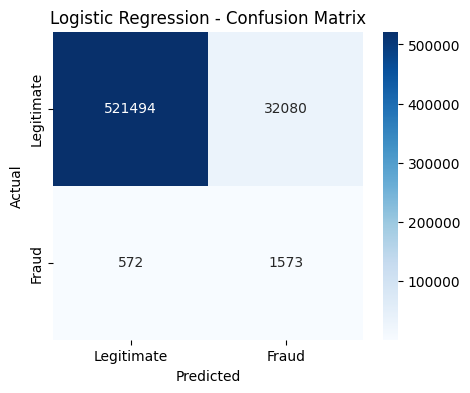

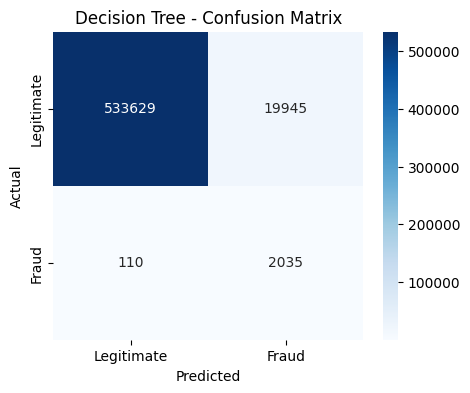

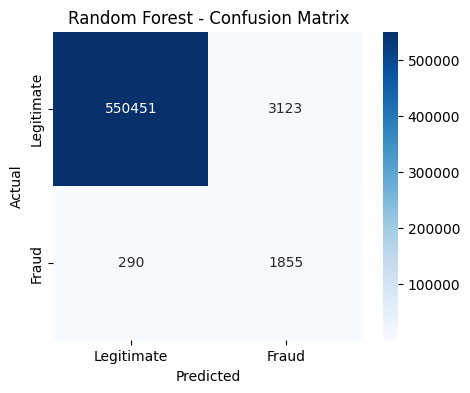

In [40]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Decision Tree
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Random Forest
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [41]:
from sklearn.metrics import classification_report

print("LOGISTIC REGRESSION")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Legitimate', 'Fraud']
))

print("\nDECISION TREE")
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=['Legitimate', 'Fraud']
))

print("\nRANDOM FOREST")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Legitimate', 'Fraud']
))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

  Legitimate       1.00      0.94      0.97    553574
       Fraud       0.05      0.73      0.09      2145

    accuracy                           0.94    555719
   macro avg       0.52      0.84      0.53    555719
weighted avg       1.00      0.94      0.97    555719


DECISION TREE
              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98    553574
       Fraud       0.09      0.95      0.17      2145

    accuracy                           0.96    555719
   macro avg       0.55      0.96      0.58    555719
weighted avg       1.00      0.96      0.98    555719


RANDOM FOREST
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    553574
       Fraud       0.37      0.86      0.52      2145

    accuracy                           0.99    555719
   macro avg       0.69      0.93      0.76    555719
weighted avg       1.00 

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
importance = rf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print("Top 15 Most Important Features:")
display(feature_importance.head(15))
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance.head(15)['Feature'][::-1],
    feature_importance.head(15)['Importance'][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

NameError: name 'rf' is not defined

In [43]:
# Show variables related to Random Forest
%whos

Variable                   Type                      Data/Info
--------------------------------------------------------------
DecisionTreeClassifier     ABCMeta                   <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
LogisticRegression         type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier     ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
StandardScaler             type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X_test                     DataFrame                            amt  gender   <...>555719 rows x 27 columns]
X_test_scaled              ndarray                   555719x27: 15004413 elems, type `float64`, 120035304 bytes (114.4745864868164 Mb)
X_train                    DataFrame                             amt  gender  <...>296675 rows x 27 columns]
X_train_scaled             ndarray                   1296675x27: 35010225 elems, type

In [44]:
# Find the Random Forest model variable

for name, value in globals().items():
    if "RandomForestClassifier" in str(type(value)):
        print("Random Forest model:", name)

RuntimeError: dictionary changed size during iteration

In [45]:
[k for k in list(globals().keys()) if "forest" in k.lower()]

['RandomForestClassifier', 'random_forest']

Top 15 Most Important Features:


,Feature,Importance
0,amt,0.591263
9,hour,0.187001
15,category_gas_transport,0.029350
17,category_grocery_pos,0.021840
24,category_shopping_net,0.020154
6,unix_time,0.011085
19,category_home,0.009681
5,city_pop,0.009659
14,category_food_dining,0.009147
21,category_misc_net,0.008798


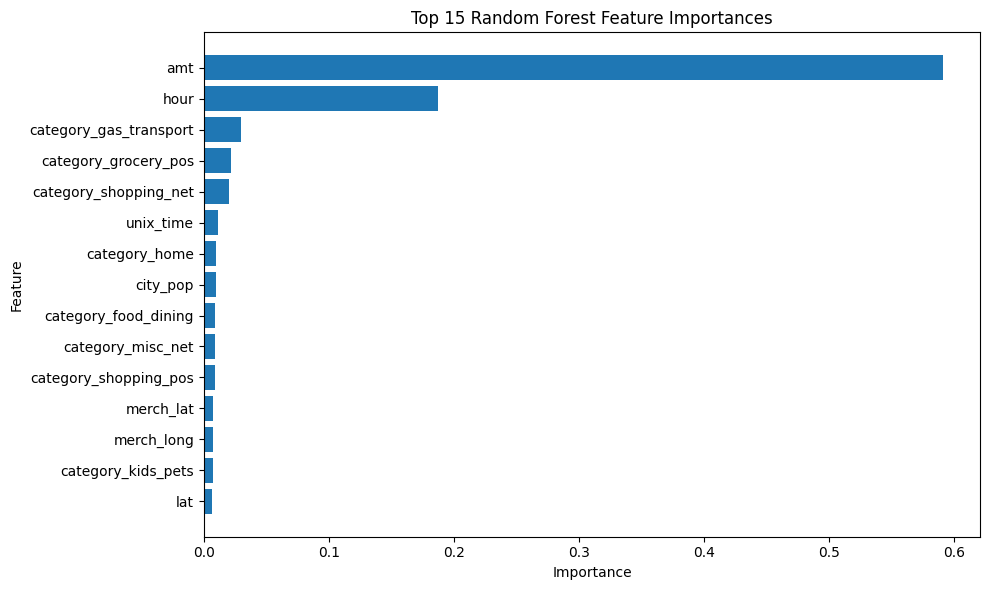

In [46]:
# Random Forest Feature Importance

importance = random_forest.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
print("Top 15 Most Important Features:")
display(feature_importance.head(15))

# Plot top 15 features
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance.head(15)["Feature"][::-1],
    feature_importance.head(15)["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [47]:
import joblib

# Save the Random Forest model
joblib.dump(random_forest, "random_forest_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [48]:
print("Features used by the model:")
print(list(X_train.columns))
print("\nNumber of features:", len(X_train.columns))

Features used by the model:
['amt', 'gender', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'hour', 'day', 'month', 'day_of_week', 'category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel']

Number of features: 27


In [49]:
import sklearn
print(sklearn.__version__)

1.2.0


In [50]:
fraud_sample = test_df[test_df["is_fraud"] == 1].iloc[0]

print("Amount:", fraud_sample["amt"])
print("Gender:", fraud_sample["gender"])
print("ZIP:", fraud_sample["zip"])
print("Latitude:", fraud_sample["lat"])
print("Longitude:", fraud_sample["long"])
print("City Population:", fraud_sample["city_pop"])
print("Merchant Latitude:", fraud_sample["merch_lat"])
print("Merchant Longitude:", fraud_sample["merch_long"])
print("Date/Time:", fraud_sample["trans_date_trans_time"])
print("Actual Category:", fraud_sample["category"])
print("Actual Label:", fraud_sample["is_fraud"])


Amount: 24.84
Gender: 0.0
ZIP: 79759.0
Latitude: 31.8599
Longitude: -102.7413
City Population: 23.0
Merchant Latitude: 32.575873
Merchant Longitude: -102.60429


KeyError: 'trans_date_trans_time'

In [51]:
fraud_sample = test_df[test_df["is_fraud"] == 1].iloc[0]

print("========== FRAUD TRANSACTION ==========")
print("Amount:", fraud_sample["amt"])
print("Gender:", fraud_sample["gender"])
print("ZIP:", fraud_sample["zip"])
print("Latitude:", fraud_sample["lat"])
print("Longitude:", fraud_sample["long"])
print("City Population:", fraud_sample["city_pop"])
print("Unix Time:", fraud_sample["unix_time"])
print("Merchant Latitude:", fraud_sample["merch_lat"])
print("Merchant Longitude:", fraud_sample["merch_long"])
print("Hour:", fraud_sample["hour"])
print("Day:", fraud_sample["day"])
print("Month:", fraud_sample["month"])
print("Day of Week:", fraud_sample["day_of_week"])
print("Actual Label:", fraud_sample["is_fraud"])

========== FRAUD TRANSACTION ==========
Amount: 24.84
Gender: 0.0
ZIP: 79759.0
Latitude: 31.8599
Longitude: -102.7413
City Population: 23.0
Unix Time: 1371852399.0
Merchant Latitude: 32.575873
Merchant Longitude: -102.60429
Hour: 22.0
Day: 21.0
Month: 6.0
Day of Week: 6.0
Actual Label: 1.0


In [52]:
# Find a transaction that the Random Forest correctly detected as fraud

fraud_indices = np.where(
    (y_test.values == 1) & (y_pred_rf == 1)
)[0]

print("Number of correctly detected fraud transactions:", len(fraud_indices))

# Take the first correctly detected fraud transaction
idx = fraud_indices[0]

print("\nTest row index:", idx)
print("\nModel prediction:", y_pred_rf[idx])
print("Actual label:", y_test.iloc[idx])

print("\nExact features used by the model:")
display(X_test.iloc[[idx]])

Number of correctly detected fraud transactions: 1855

Test row index: 1767

Model prediction: 1
Actual label: 1

Exact features used by the model:


,amt,gender,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,hour,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
1767,780.52,1,53803,42.5545,-90.3508,1306,1371853942,42.461127,-91.147148,22,...,0,0,0,0,1,0,0,0,0,0


In [53]:
print("Exact values to use:")
print(X_test.iloc[idx].to_dict())

Exact values to use:
{'amt': 780.52, 'gender': 1.0, 'zip': 53803.0, 'lat': 42.5545, 'long': -90.3508, 'city_pop': 1306.0, 'unix_time': 1371853942.0, 'merch_lat': 42.461127000000005, 'merch_long': -91.147148, 'hour': 22.0, 'day': 21.0, 'month': 6.0, 'day_of_week': 6.0, 'category_entertainment': 0.0, 'category_food_dining': 0.0, 'category_gas_transport': 0.0, 'category_grocery_net': 0.0, 'category_grocery_pos': 0.0, 'category_health_fitness': 0.0, 'category_home': 0.0, 'category_kids_pets': 0.0, 'category_misc_net': 1.0, 'category_misc_pos': 0.0, 'category_personal_care': 0.0, 'category_shopping_net': 0.0, 'category_shopping_pos': 0.0, 'category_travel': 0.0}


In [54]:
from datetime import datetime

print(datetime.fromtimestamp(1371853942))

2013-06-22 04:02:22
